In [41]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel
from typing import List
from dotenv import load_dotenv

load_dotenv()
llm = init_chat_model("openai:gpt-4o")  

In [42]:
class State(TypedDict):
    dish: str
    ingredients: list[dict]
    recipe_steps: str
    plating_instructions: str

class Ingredient(BaseModel):
    name: str
    quantity: str
    unit: str

class IngredientOutput(BaseModel):
    ingredients: List[Ingredient]

In [43]:
def list_ingredients(state: State):
    structured_llm  = llm.with_structured_output(IngredientOutput)

    response = structured_llm.invoke(
        f"List 5-8 ingredients needed to make {state['dish']}"
    )

    return {
        "ingredients" : response.ingredients,
    }

def create_recipe(state: State):
    response = llm.invoke(
        f"Write a step by step cooking instruction for {state['dish']}, using these ingredients: {state['ingredients']}"
    )

    return {
        "recipe_steps" : response.content,
    }

def describe_plating(state: State):
    response = llm.invoke(
        f"Describe how to beautifully plate this dish: {state['dish']} based on this recipe: {state['recipe_steps']}"
    )

    return {
        "plating_instructions" : response.content,
    }

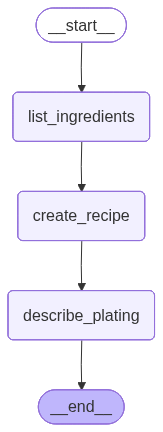

In [44]:
graph_builder = StateGraph(State)

graph_builder.add_node(
    "list_ingredients",
    list_ingredients,
)


graph_builder.add_node(
    "create_recipe",
    create_recipe,
)


graph_builder.add_node(
    "describe_plating",
    describe_plating
)

graph_builder.add_edge(START, "list_ingredients")
graph_builder.add_edge("list_ingredients", "create_recipe")
graph_builder.add_edge("create_recipe", "describe_plating")
graph_builder.add_edge("describe_plating", END)

graph = graph_builder.compile()
graph

In [45]:
graph.invoke({
    "dish" : "hummus"
})

{'dish': 'hummus',
 'ingredients': [Ingredient(name='Chickpeas', quantity='1', unit='cup'),
  Ingredient(name='Tahini', quantity='1/4', unit='cup'),
  Ingredient(name='Garlic cloves', quantity='2', unit='units'),
  Ingredient(name='Lemon juice', quantity='2', unit='tablespoons'),
  Ingredient(name='Olive oil', quantity='2', unit='tablespoons'),
  Ingredient(name='Salt', quantity='to taste', unit='sprinkle'),
  Ingredient(name='Cumin', quantity='1', unit='teaspoon')],
 'recipe_steps': "Here's a step-by-step guide to making hummus using the ingredients you provided:\n\n### Ingredients:\n- 1 cup Chickpeas (canned or cooked from dried)\n- 1/4 cup Tahini\n- 2 Garlic cloves\n- 2 tablespoons Lemon juice (freshly squeezed)\n- 2 tablespoons Olive oil\n- Salt to taste\n- 1 teaspoon Cumin\n\n### Instructions:\n\n1. **Prepare the Chickpeas**:\n   - If using canned chickpeas, drain and rinse them under cold water. If using dried chickpeas, ensure they are cooked and cooled.\n\n2. **Blend the Ingred